## 1. Setup and Imports

In [1]:
%pip install numpy pandas matplotlib seaborn wordcloud

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.5 MB 6.8 MB/s eta 0:00:02
   ------------------------ --------------- 7.6/12.5 MB 21.7 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.5 MB 26.4 MB/s eta 0:00:01
   ---------------------------------------- 12.5/12.5 MB 19.8 MB/s  0:00:00
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------------------------------- ------- 7.9/9.8 MB 38.2 MB/s


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

warnings.filterwarnings("ignore")

# Consistent plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Data Loading



In [10]:
DATA_DIR = "../Data/raw"  # change this if your files live elsewhere

LABEL_COLUMNS = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate",
]


def load_csv(filename: str, data_dir: str = DATA_DIR) -> pd.DataFrame:
    """Load a CSV file from the data directory into a DataFrame.

    Args:
        filename: Name of the CSV file (e.g. 'train.csv').
        data_dir: Directory where the dataset files are stored.

    Returns:
        A pandas DataFrame with the file's contents.

    Raises:
        FileNotFoundError: If the file does not exist at the expected path.
    """
    path = os.path.join(data_dir, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Could not find '{path}'. Download the dataset from Kaggle and "
            f"place it under '{data_dir}/', or update DATA_DIR."
        )
    return pd.read_csv(path)


train_df = load_csv("train.csv")
test_df = load_csv("test.csv")

try:
    test_labels_df = load_csv("test_labels.csv")
except FileNotFoundError:
    test_labels_df = None
    print("test_labels.csv not found — this file is optional for pure EDA.")

print(f"train shape: {train_df.shape}")
print(f"test shape:  {test_df.shape}")


train shape: (159571, 8)
test shape:  (153164, 2)


In [11]:
train_df.head()


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## 3. General Overview

In [12]:
def dataset_overview(df: pd.DataFrame, name: str = "dataset") -> None:
    """Print a quick summary of a DataFrame: shape, dtypes, missing values."""
    print(f"--- Overview: {name} ---")
    print(f"Shape: {df.shape}")
    print("\nColumn dtypes:")
    print(df.dtypes)
    print("\nMissing values per column:")
    print(df.isnull().sum())
    print(f"\nDuplicate comment_text rows: {df['comment_text'].duplicated().sum()}")


dataset_overview(train_df, "train")


--- Overview: train ---
Shape: (159571, 8)

Column dtypes:
id                 str
comment_text       str
toxic            int64
severe_toxic     int64
obscene          int64
threat           int64
insult           int64
identity_hate    int64
dtype: object

Missing values per column:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Duplicate comment_text rows: 0


In [13]:
dataset_overview(test_df, "test")


--- Overview: test ---
Shape: (153164, 2)

Column dtypes:
id              str
comment_text    str
dtype: object

Missing values per column:
id              0
comment_text    0
dtype: int64

Duplicate comment_text rows: 0


## 4. Label Distribution


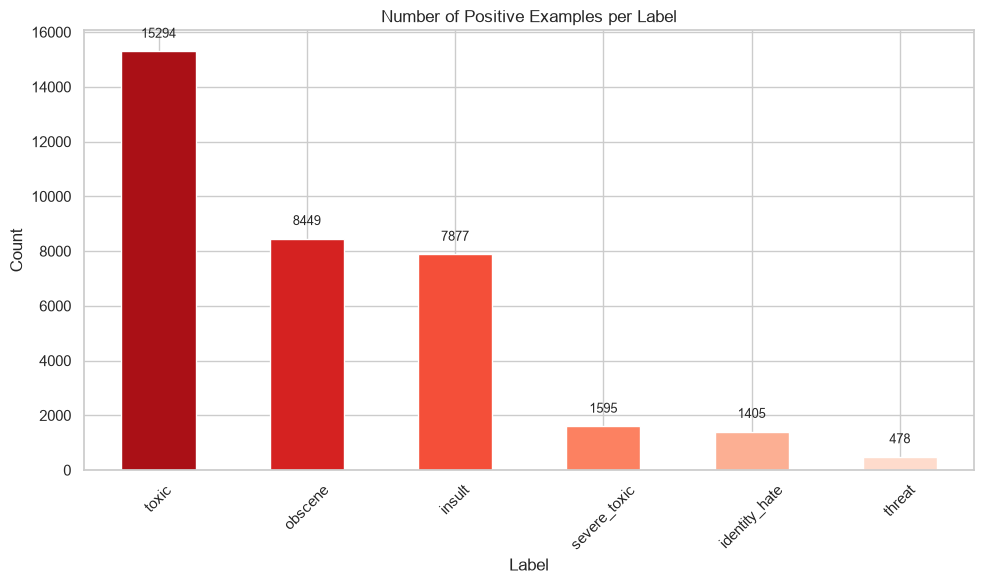

Positive rate (%) per label:
toxic            9.58
obscene          5.29
insult           4.94
severe_toxic     1.00
identity_hate    0.88
threat           0.30
dtype: float64


In [14]:
def plot_label_distribution(df: pd.DataFrame, label_columns: list) -> None:
    """Bar plot of the positive-class count for each label."""
    counts = df[label_columns].sum().sort_values(ascending=False)

    ax = counts.plot(kind="bar", color=sns.color_palette("Reds_r", len(counts)))
    ax.set_title("Number of Positive Examples per Label")
    ax.set_ylabel("Count")
    ax.set_xlabel("Label")
    for i, v in enumerate(counts):
        ax.text(i, v + 500, str(v), ha="center", fontsize=9)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("Positive rate (%) per label:")
    print((counts / len(df) * 100).round(2))


plot_label_distribution(train_df, LABEL_COLUMNS)


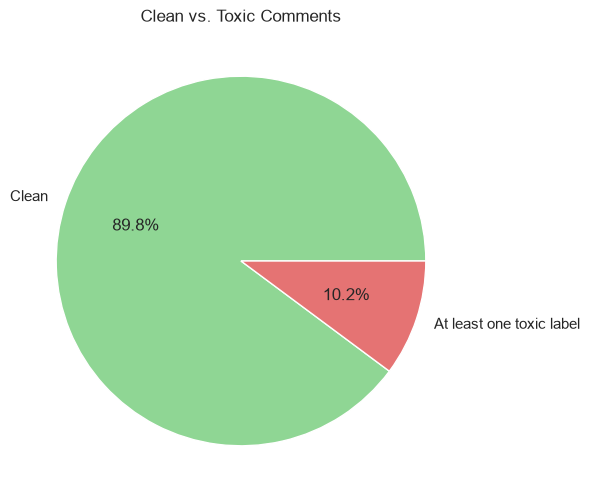

Clean comments:       143346 (89.83%)
At least one label:   16225 (10.17%)


In [15]:
def clean_vs_toxic_ratio(df: pd.DataFrame, label_columns: list) -> None:
    """Show how many comments have no toxic label at all ('clean')."""
    has_any_label = df[label_columns].sum(axis=1) > 0
    clean_count = (~has_any_label).sum()
    toxic_count = has_any_label.sum()

    labels = ["Clean", "At least one toxic label"]
    values = [clean_count, toxic_count]

    plt.pie(values, labels=labels, autopct="%1.1f%%", colors=["#8fd694", "#e57373"])
    plt.title("Clean vs. Toxic Comments")
    plt.show()

    print(f"Clean comments:       {clean_count} ({clean_count / len(df):.2%})")
    print(f"At least one label:   {toxic_count} ({toxic_count / len(df):.2%})")


clean_vs_toxic_ratio(train_df, LABEL_COLUMNS)


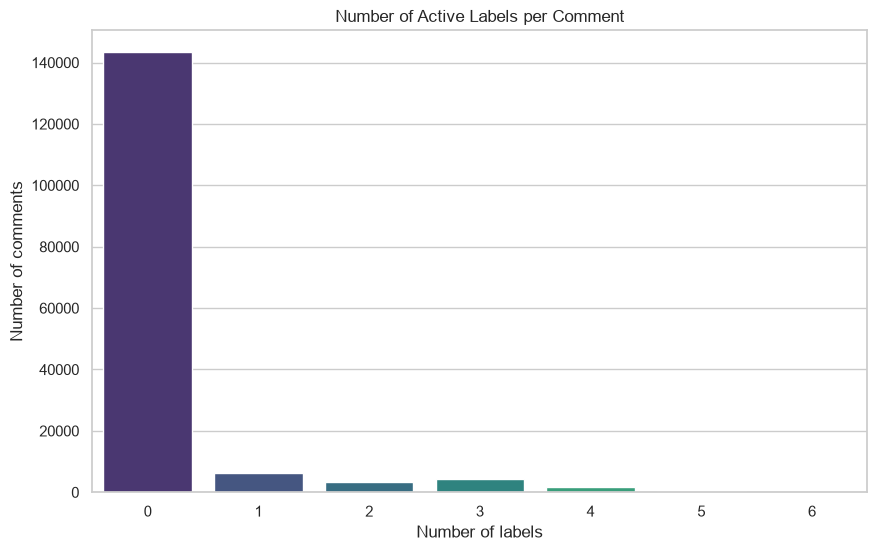

0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64


In [16]:
def plot_labels_per_comment(df: pd.DataFrame, label_columns: list) -> None:
    """Distribution of how many labels are active per comment."""
    label_count = df[label_columns].sum(axis=1)

    ax = sns.countplot(x=label_count, palette="viridis")
    ax.set_title("Number of Active Labels per Comment")
    ax.set_xlabel("Number of labels")
    ax.set_ylabel("Number of comments")
    plt.show()

    print(label_count.value_counts().sort_index())


plot_labels_per_comment(train_df, LABEL_COLUMNS)


## 5. Label Co-occurrence


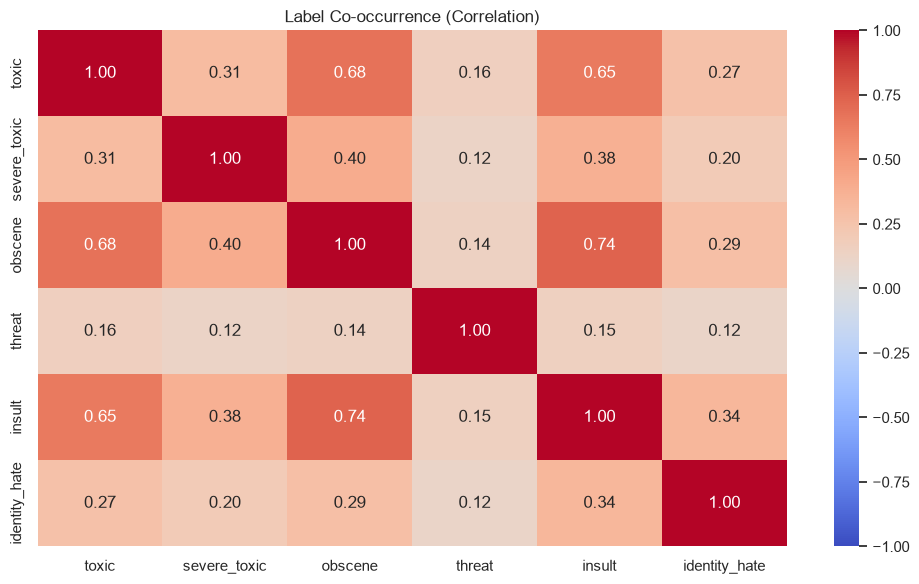

In [17]:
def plot_label_correlation(df: pd.DataFrame, label_columns: list) -> None:
    """Heatmap of pairwise correlations between the label columns."""
    corr = df[label_columns].corr()

    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Label Co-occurrence (Correlation)")
    plt.tight_layout()
    plt.show()


plot_label_correlation(train_df, LABEL_COLUMNS)


## 6. Comment Text Length Analysis


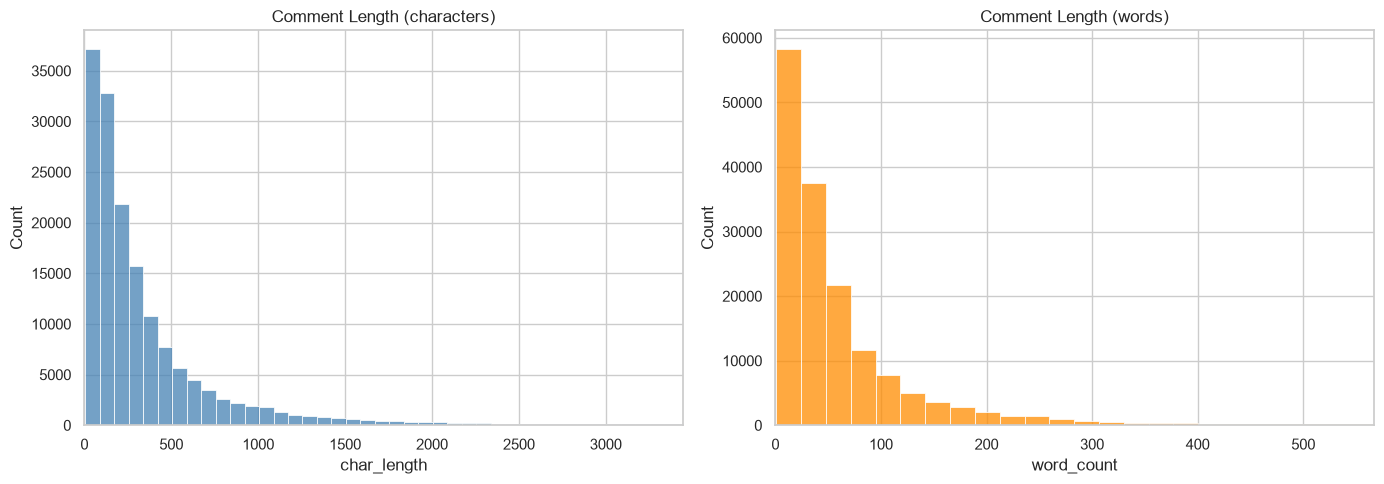

,char_length,word_count
count,159571.000000,159571.000000
mean,394.073221,67.273527
std,590.720282,99.230702
min,6.000000,1.000000
25%,96.000000,17.000000
50%,205.000000,36.000000
75%,435.000000,75.000000
max,5000.000000,1411.000000


In [18]:
def add_text_length_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add character-count and word-count columns to a copy of the DataFrame."""
    df = df.copy()
    df["char_length"] = df["comment_text"].str.len()
    df["word_count"] = df["comment_text"].str.split().str.len()
    return df


train_df = add_text_length_features(train_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df["char_length"], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Comment Length (characters)")
axes[0].set_xlim(0, train_df["char_length"].quantile(0.99))

sns.histplot(train_df["word_count"], bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("Comment Length (words)")
axes[1].set_xlim(0, train_df["word_count"].quantile(0.99))

plt.tight_layout()
plt.show()

train_df[["char_length", "word_count"]].describe()


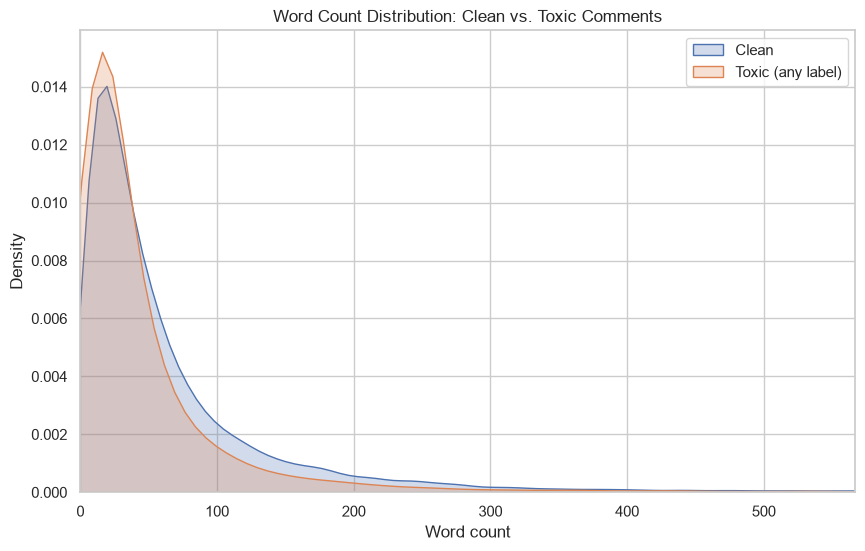

In [19]:
def plot_length_by_label(df: pd.DataFrame, label_columns: list) -> None:
    """Compare word-count distributions between toxic and clean comments."""
    is_toxic = df[label_columns].sum(axis=1) > 0

    plt.figure(figsize=(10, 6))
    sns.kdeplot(df.loc[~is_toxic, "word_count"], label="Clean", fill=True)
    sns.kdeplot(df.loc[is_toxic, "word_count"], label="Toxic (any label)", fill=True)
    plt.xlim(0, df["word_count"].quantile(0.99))
    plt.title("Word Count Distribution: Clean vs. Toxic Comments")
    plt.xlabel("Word count")
    plt.legend()
    plt.show()


plot_length_by_label(train_df, LABEL_COLUMNS)


## 7. Most Frequent Words per Label

In [21]:
def basic_clean(text: str) -> str:
    """Lightweight text cleaning used only for exploratory word frequency.

    Args:
        text: Raw comment text.

    Returns:
        Lowercased text with URLs, IP addresses, and punctuation stripped.
    """
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)          # URLs
    text = re.sub(r"\d+\.\d+\.\d+\.\d+", " ", text)            # IP addresses
    text = re.sub(r"[^a-z\s]", " ", text)                       # punctuation/digits
    text = re.sub(r"\s+", " ", text).strip()
    return text


sample_clean = train_df["comment_text"].head(3).apply(basic_clean)
for original, cleaned in zip(train_df["comment_text"].head(3), sample_clean):
    print("RAW:    ", original[:100].replace("\n", " "))
    print("CLEANED:", cleaned[:100])
    print("-" * 80)


RAW:     Explanation Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't 
CLEANED: explanation why the edits made under my username hardcore metallica fan were reverted they weren t v
--------------------------------------------------------------------------------
RAW:     D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11
CLEANED: d aww he matches this background colour i m seemingly stuck with thanks talk january utc
--------------------------------------------------------------------------------
RAW:     Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant 
CLEANED: hey man i m really not trying to edit war it s just that this guy is constantly removing relevant in
--------------------------------------------------------------------------------


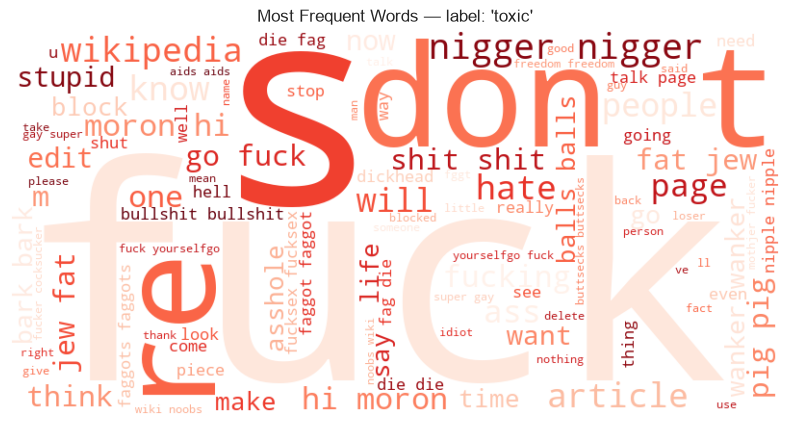

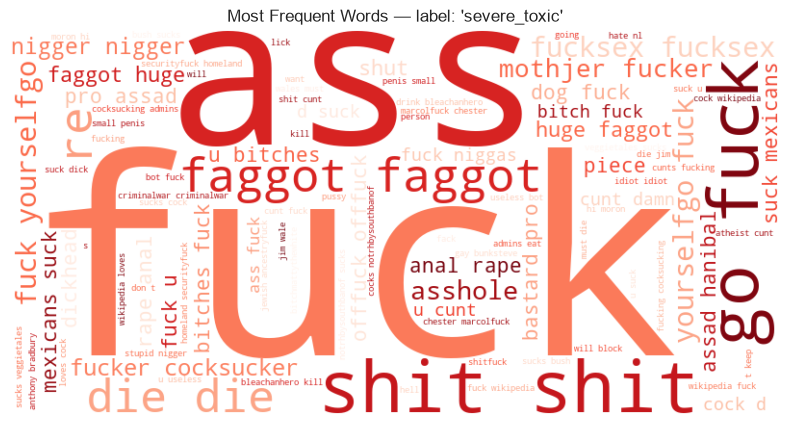

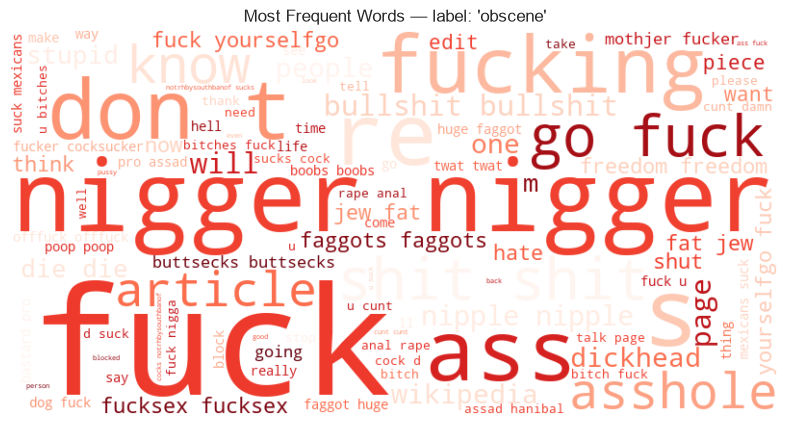

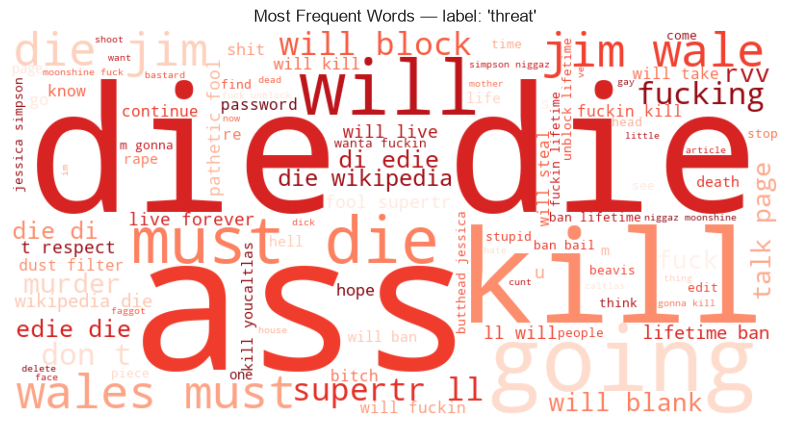

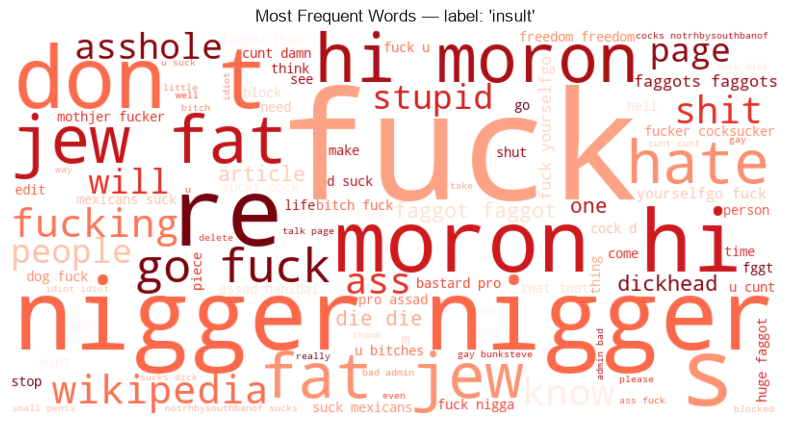

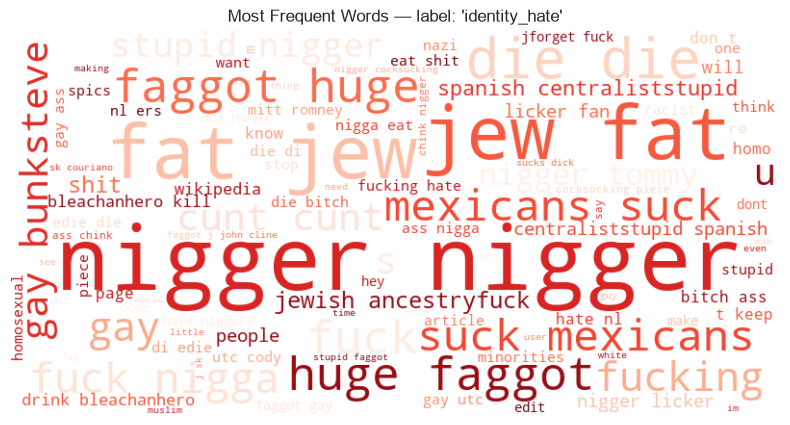

In [22]:
def plot_wordcloud_for_label(df: pd.DataFrame, label: str, max_words: int = 100) -> None:
    """Generate and display a word cloud for comments positive on `label`."""
    subset = df.loc[df[label] == 1, "comment_text"].apply(basic_clean)
    text = " ".join(subset)

    if not text.strip():
        print(f"No comments found for label '{label}'.")
        return

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=STOPWORDS,
        max_words=max_words,
        colormap="Reds",
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Most Frequent Words — label: '{label}'")
    plt.show()


for label in LABEL_COLUMNS:
    plot_wordcloud_for_label(train_df, label)


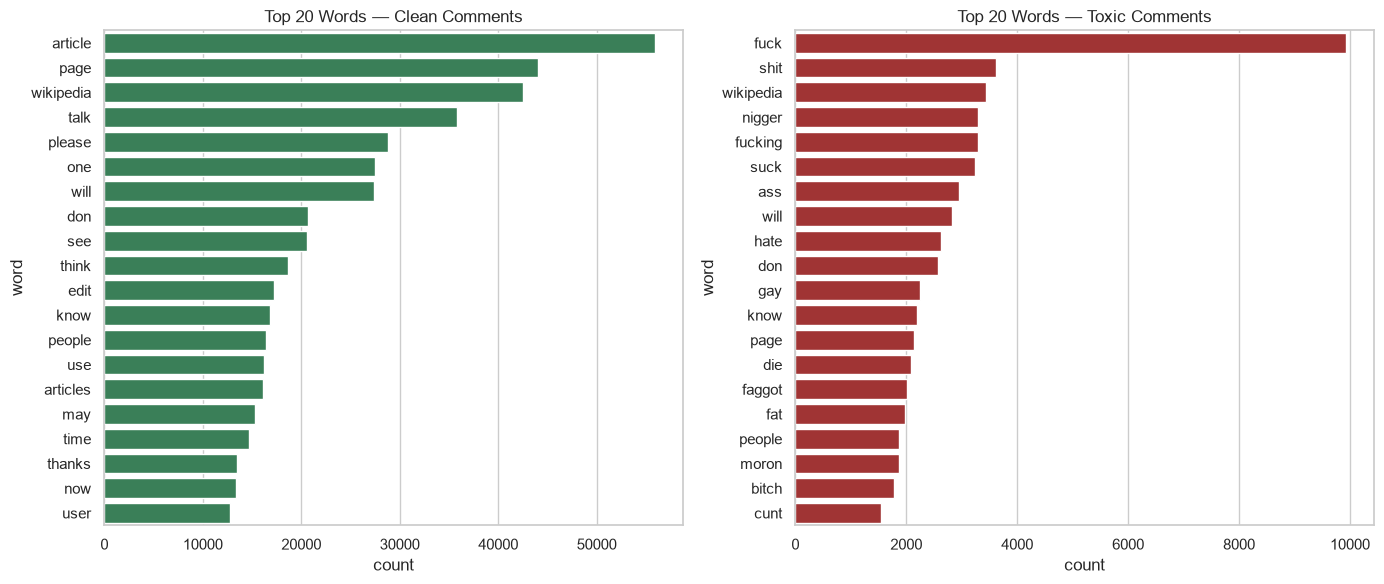

In [23]:
def top_n_words(texts: pd.Series, n: int = 20, stopwords=STOPWORDS) -> pd.DataFrame:
    """Return the n most common words (excluding stopwords) in a series of texts."""
    counter = Counter()
    for text in texts:
        words = [w for w in basic_clean(text).split() if w not in stopwords and len(w) > 2]
        counter.update(words)
    return pd.DataFrame(counter.most_common(n), columns=["word", "count"])


top_words_clean = top_n_words(
    train_df.loc[train_df[LABEL_COLUMNS].sum(axis=1) == 0, "comment_text"]
)
top_words_toxic = top_n_words(
    train_df.loc[train_df["toxic"] == 1, "comment_text"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top_words_clean, x="count", y="word", ax=axes[0], color="seagreen")
axes[0].set_title("Top 20 Words — Clean Comments")

sns.barplot(data=top_words_toxic, x="count", y="word", ax=axes[1], color="firebrick")
axes[1].set_title("Top 20 Words — Toxic Comments")

plt.tight_layout()
plt.show()
